## EDA - Internaciones Hospitalarias

An?lisis exploratorio b?sico para validar calidad de datos y entender distribuciones.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Carga de Datos

Se carga el dataset crudo desde `data/raw` para iniciar el an?lisis exploratorio.

In [4]:
df = pd.read_csv("../data/raw/healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Calidad de Datos

Revisamos valores nulos para identificar posibles problemas de completitud.

In [5]:
# Valores nulos
df.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

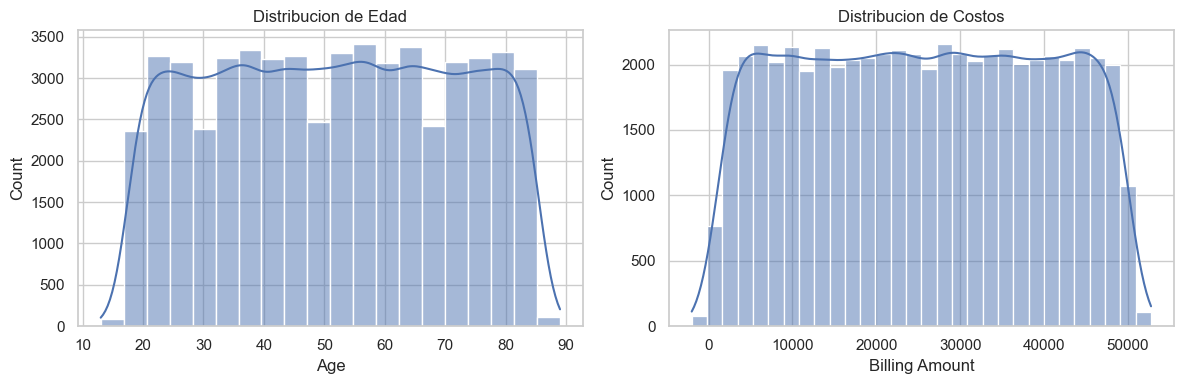

In [6]:
# Distribuciones basicas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de Edad")

sns.histplot(df["Billing Amount"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribucion de Costos")

plt.tight_layout()

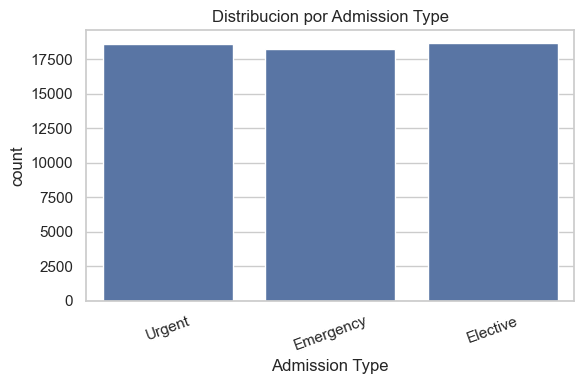

In [7]:
# Distribucion por tipo de admision
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Admission Type")
plt.title("Distribucion por Admission Type")
plt.xticks(rotation=20)
plt.tight_layout()

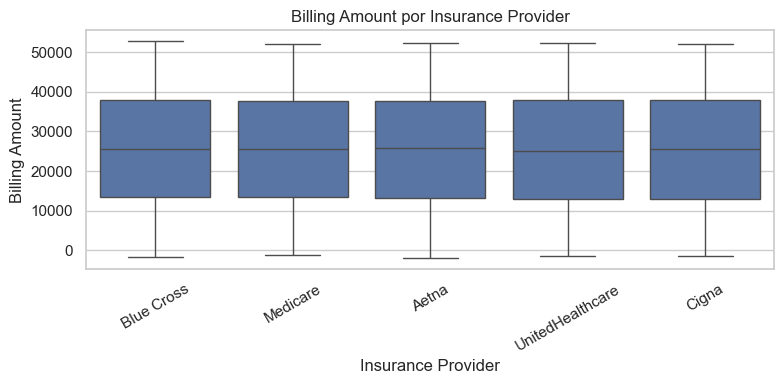

In [8]:
# Boxplot de costos por aseguradora
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Insurance Provider", y="Billing Amount")
plt.title("Billing Amount por Insurance Provider")
plt.xticks(rotation=30)
plt.tight_layout()

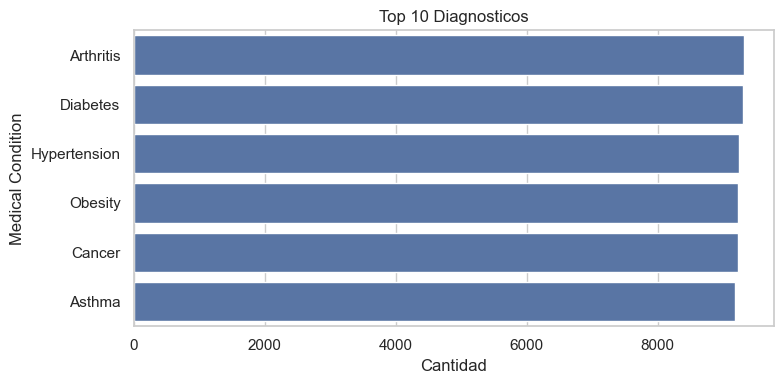

In [9]:
# Histograma de diagn?sticos (Top 10)
top_diag = df["Medical Condition"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_diag.values, y=top_diag.index)
plt.title("Top 10 Diagnosticos")
plt.xlabel("Cantidad")
plt.tight_layout()

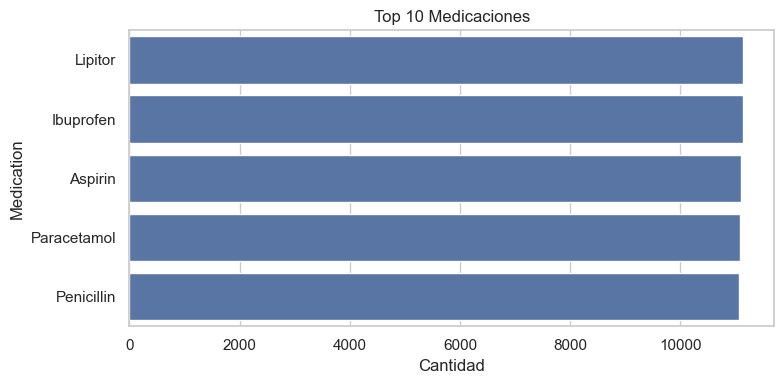

In [10]:
# Histograma de medicacion (Top 10)
top_med = df["Medication"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_med.values, y=top_med.index)
plt.title("Top 10 Medicaciones")
plt.xlabel("Cantidad")
plt.tight_layout()

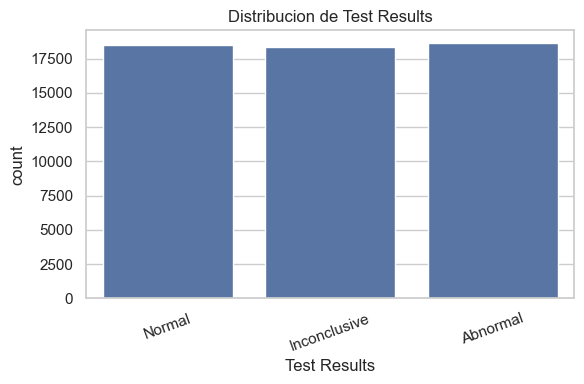

In [11]:
# Distribucion de resultados de test
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Test Results")
plt.title("Distribucion de Test Results")
plt.xticks(rotation=20)
plt.tight_layout()

In [12]:
# Deteccion de outliers con IQR
q1 = df["Billing Amount"].quantile(0.25)
q3 = df["Billing Amount"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["Billing Amount"] < lower) | (df["Billing Amount"] > upper)]
len(outliers)

0

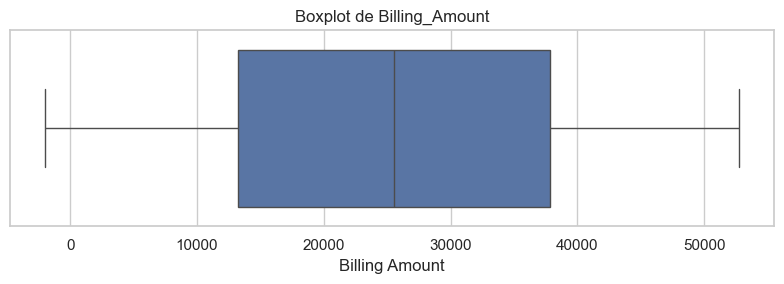

In [13]:
# Visualizacion de outliers
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["Billing Amount"]) 
plt.title("Boxplot de Billing_Amount")
plt.tight_layout()

## Duracion de Internacion

Calculamos la estadia en dias entre admision y alta.

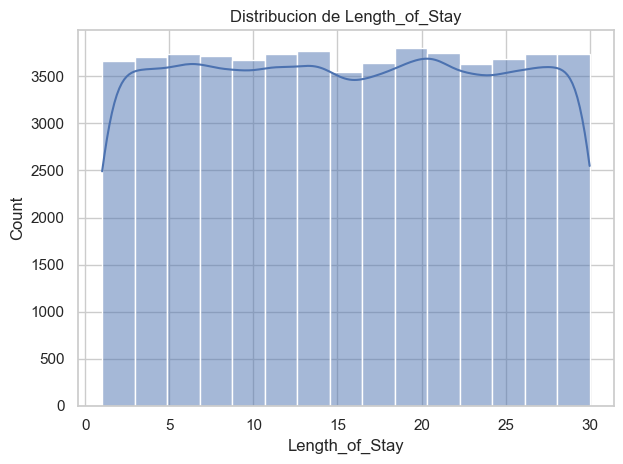

In [14]:
# Longitud de internacion
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df["Length_of_Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

sns.histplot(df["Length_of_Stay"], bins=15, kde=True)
plt.title("Distribucion de Length_of_Stay")
plt.tight_layout()

## Relaciones Entre Variables

Exploramos relaciones entre costos, duracion y variables categoricas.

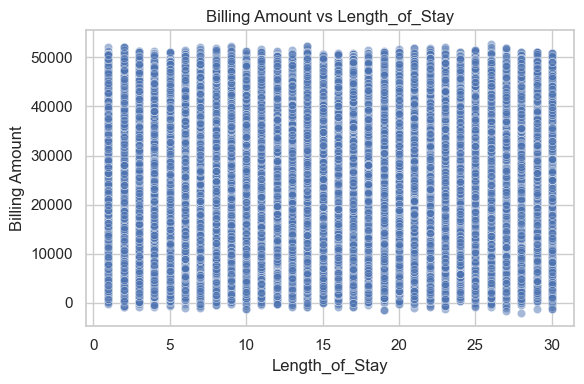

In [15]:
# Relacion entre costo y duracion
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Length_of_Stay", y="Billing Amount", alpha=0.5)
plt.title("Billing Amount vs Length_of_Stay")
plt.tight_layout()

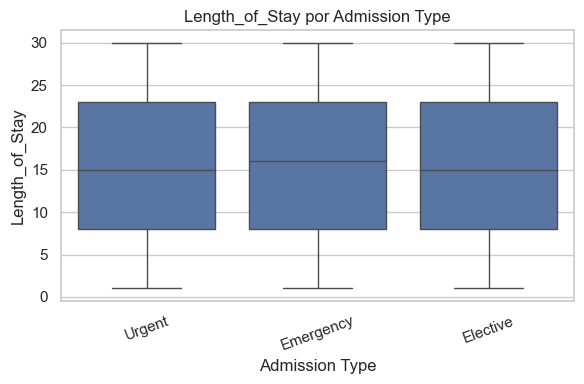

In [16]:
# Duracion por tipo de admision
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Admission Type", y="Length_of_Stay")
plt.title("Length_of_Stay por Admission Type")
plt.xticks(rotation=20)
plt.tight_layout()

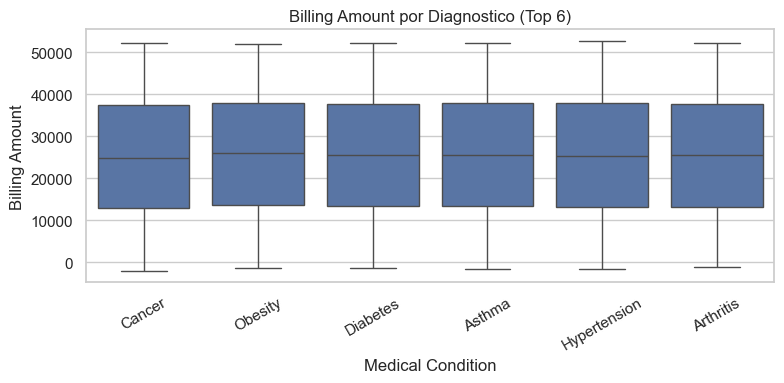

In [17]:
# Costo por diagnostico (Top 10)
top_diag = df["Medical Condition"].value_counts().head(6).index
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[df["Medical Condition"].isin(top_diag)], x="Medical Condition", y="Billing Amount")
plt.title("Billing Amount por Diagnostico (Top 6)")
plt.xticks(rotation=30)
plt.tight_layout()

Las internaciones por Cancer muestran costos individuales altos y una distribución elevada en comparación con otros diagnósticos, aunque el mayor costo total acumulado corresponde a Diabetes.

## Chequeo de Valores Extremos

Listado de casos con costos y estadi­as mas altas para revision.

In [18]:
# Top 10 costos mas altos
df.nlargest(10, "Billing Amount")[["Name", "Medical Condition", "Hospital", "Billing Amount", "Length_of_Stay"]]

,Name,Medical Condition,Hospital,Billing Amount,Length_of_Stay
36349,tOdd CARrILlO,Hypertension,Griffin Group,52764.276736,26
34613,kARen klInE,Cancer,Hernandez-Morton,52373.032374,14
51313,kARen klInE,Cancer,Hernandez-Morton,52373.032374,14
5735,DAVId SanDOvaL,Hypertension,Sons and Bailey,52271.663747,9
7088,kathRYN GoNzales,Diabetes,Miller Ltd,52211.852966,1
1574,BRETT mARshAll,Asthma,PLC Garner,52181.837792,7
6663,LAuRie hOod,Arthritis,Walker-Garcia,52170.036854,2
52826,LAuRie hOod,Arthritis,Walker-Garcia,52170.036854,2
33117,JUstIn CLark,Cancer,Ruiz-Anthony,52154.237722,23
34368,sCotT pOWElL,Cancer,George-Gonzalez,52102.240889,9


Los casos con mayor Billing Amount no siempre coinciden con estancias prolongadas; por ejemplo, aparece una internacion por Diabetes de solo 1 dia dentro del top 5 de costos, lo que sugiere que la complejidad clinica o la intensidad del tratamiento tambien influyen en el costo final.

In [19]:
# Top 10 estadias mas largas
df.nlargest(10, "Length_of_Stay")[["Name", "Medical Condition", "Hospital", "Billing Amount", "Length_of_Stay"]]

,Name,Medical Condition,Hospital,Billing Amount,Length_of_Stay
3,andrEw waTtS,Diabetes,"Hernandez Rogers and Vang,",37909.782410,30
9,ChRISTopher BerG,Cancer,Padilla-Walker,19784.631062,30
82,SeaN jenniNGs,Diabetes,Clark-Johnson,20257.544283,30
140,aPRIL VAleNCIA,Diabetes,Levine-Miller,22356.226492,30
141,riTA archER,Diabetes,"and Marquez Silva Smith,",48995.980592,30
152,JENnIfEr mCmillan,Obesity,Rodriguez and Sons,15475.403237,30
184,ChRiSTINA MArTin,Diabetes,Inc Lee,17670.505217,30
203,ALAn tayLor,Diabetes,"Hunt, Carlson and Cherry",36339.819081,30
205,asHLEY webb ddS,Cancer,"Gordon, Fox Lane and",40469.566259,30
222,LAURen RAMireZ,Asthma,Harrison-Parker,1791.389001,30


# Validacion Post-Limpieza (SQLite)

In [20]:
import sqlite3
db_path = "../database/health.db"
conn = sqlite3.connect(db_path)
clean = pd.read_sql("SELECT * FROM clean_admissions", conn)
conn.close()
clean.head()

,Patient_ID,Patient_Name,Age,Gender,Blood_Type,Admission_Date,Discharge_Date,Diagnosis,Doctor,Hospital,Billing_Amount,Admission_Type,Insurance,Medication,Test_Results,length_of_stay,age_group
0,P715a736b93,Bobby Jackson,30,Male,B-,2024-01-31,2024-02-02,Cancer,Matthew Smith,Sons and Miller,18856.281306,Urgent,Blue Cross,Paracetamol,Normal,2,18-34
1,Pcfb2462b36,Leslie Terry,62,Male,A+,2019-08-20,2019-08-26,Obesity,Samantha Davies,Kim Inc,33643.327287,Emergency,Medicare,Ibuprofen,Inconclusive,6,50-64
2,P62a3e8856d,Danny Smith,76,Female,A-,2022-09-22,2022-10-07,Obesity,Tiffany Mitchell,Cook PLC,27955.096079,Emergency,Aetna,Aspirin,Normal,15,65+
3,Pf23a8f8528,Andrew Watts,28,Female,O+,2020-11-18,2020-12-18,Diabetes,Kevin Wells,"Hernandez Rogers and Vang,",37909.782410,Elective,Medicare,Ibuprofen,Abnormal,30,18-34
4,P1ae8e53c7c,Adrienne Bell,43,Female,AB+,2022-09-19,2022-10-09,Cancer,Kathleen Hanna,White-White,14238.317814,Urgent,Aetna,Penicillin,Abnormal,20,35-49


In [21]:
# Comparacion de registros (crudo vs limpio)
pd.DataFrame({"raw_rows": [len(df)], "clean_rows": [len(clean)]})

,raw_rows,clean_rows
0,55500,55392


In [22]:
# Chequeo rapido de nulos post-limpieza
clean.isna().sum()

Patient_ID        0
Patient_Name      0
Age               0
Gender            0
Blood_Type        0
Admission_Date    0
Discharge_Date    0
Diagnosis         0
Doctor            0
Hospital          0
Billing_Amount    0
Admission_Type    0
Insurance         0
Medication        0
Test_Results      0
length_of_stay    0
age_group         0
dtype: int64

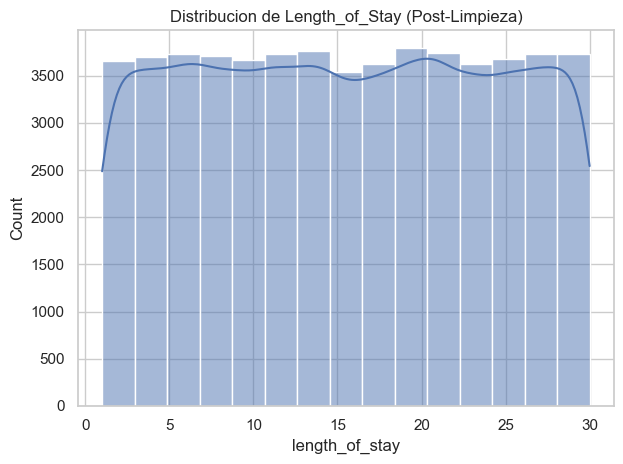

In [23]:
# Distribucion de Length_of_Stay post-limpieza
sns.histplot(clean["length_of_stay"], bins=15, kde=True)
plt.title("Distribucion de Length_of_Stay (Post-Limpieza)")
plt.tight_layout()

## Conclusiones

- El dataset presenta una estructura consistente y sin volumen relevante de nulos en las variables principales, lo que permite avanzar con analisis descriptivos y de negocio.
- La distribucion de costos muestra una dispersion amplia y presencia de valores extremos, por lo que el promedio debe interpretarse con cautela y complementarse con otras medidas descriptivas.
- La duracion de internacion es una variable relevante porque se relaciona con el costo del episodio, aunque no explica por si sola los casos de mayor facturacion.
- Los tipos de admision, diagnosticos, aseguradoras y resultados de test ofrecen segmentos utiles para comparar diferencias operativas y financieras dentro del dataset.
- Los casos extremos muestran que un Billing Amount elevado no siempre coincide con una estancia prolongada; aparecen internaciones cortas entre los registros mas caros, lo que sugiere influencia de la complejidad clinica o de la intensidad del tratamiento.
- Cancer presenta internaciones de alto costo individual, pero Diabetes lidera el costo total acumulado, lo que refuerza la diferencia entre analizar distribucion de costos y costo total por diagnostico.
- La validacion post-limpieza confirma que la vista clean_admissions conserva registros analizables y deja una base confiable para KPIs y analisis en SQL.
